In [1]:



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### Import IMDB datasets

In [2]:
movies = pd.read_csv('E:\\University Stuff\\Third year\\movie_recommender_research\\datasets\\movie_lens_2m\\movies.csv')

#### _Clean the data_

In [3]:
# the function to extract titles
def extract_title(title):
   year = title[len(title)-5:len(title)-1]

   # some movies do not have the info about year in the column title. So, we should take care of the case as well.

   if year.isnumeric():
      title_no_year = title[:len(title)-7]
      return title_no_year
   else:
      return title
# the function to extract years
def extract_year(title):
   year = title[len(title)-5:len(title)-1]
   # some movies do not have the info about year in the column title. So, we should take care of the case as well.
   if year.isnumeric():
      return int(year)
   else:
      return np.nan
# change the column name from title to title_year
movies.rename(columns={'title':'title_year'}, inplace=True)
# remove leading and ending whitespaces in title_year
movies['title_year'] = movies['title_year'].apply(lambda x: x.strip())
# create the columns for title and year
movies['title'] = movies['title_year'].apply(extract_title)
movies['year'] = movies['title_year'].apply(extract_year)

#### Remove movies with no genres

In [4]:
movies[movies['genres']== '(no genres listed)'].shape
print('Amount of entries before null genre removal:',len(movies))
movies = movies[~(movies['genres']=='(no genres listed)')].reset_index(drop=True)
print('Amount of entries after null genre removal:',len(movies))

Amount of entries before null genre removal: 27278
Amount of entries after null genre removal: 27032


In [5]:
movies.head(1000)

,movieId,title_year,genres,title,year
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,Toy Story,1995.0
1,2,Jumanji (1995),Adventure|Children|Fantasy,Jumanji,1995.0
2,3,Grumpier Old Men (1995),Comedy|Romance,Grumpier Old Men,1995.0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,Waiting to Exhale,1995.0
4,5,Father of the Bride Part II (1995),Comedy,Father of the Bride Part II,1995.0
...,...,...,...,...,...
995,1014,Pollyanna (1960),Children|Comedy|Drama,Pollyanna,1960.0
996,1015,Homeward Bound: The Incredible Journey (1993),Adventure|Children|Drama,Homeward Bound: The Incredible Journey,1993.0
997,1016,"Shaggy Dog, The (1959)",Children|Comedy,"Shaggy Dog, The",1959.0
998,1017,Swiss Family Robinson (1960),Adventure|Children,Swiss Family Robinson,1960.0


#### Counting the number of occurences for each

In [6]:
# remove '|' in the genres column
movies['genres'] = movies['genres'].str.replace('|',' ')


# Populate the dictionary
counts = {}
for i in movies.index:
    for g in movies.loc[i, 'genres'].split(' '):
        if g not in counts:
            counts[g] = 1
        else:
            counts[g] = counts[g] + 1

e:\university stuff\third year\movie_recommender_research\venv\lib\site-packages\ipykernel_launcher.py:2: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  


Text(0, 0.5, 'Counts')

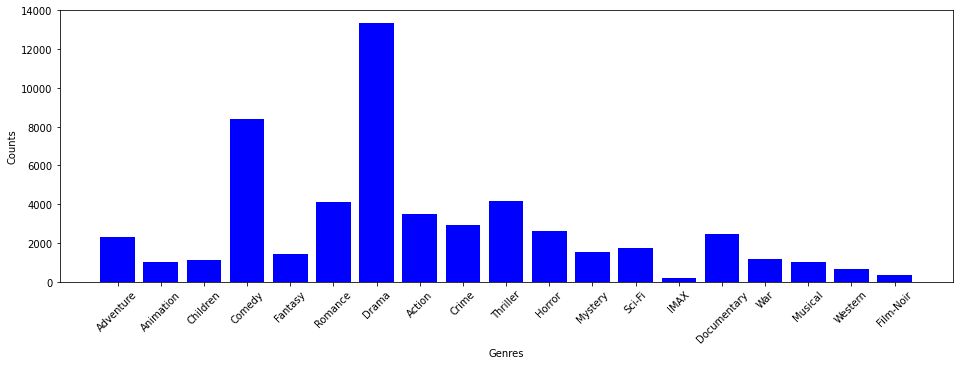

In [7]:
# create a bar chart
f,ax = plt.subplots(1,1,figsize=(16,5))
plt.bar(list(counts.keys()), counts.values(), color='b')
plt.xticks(rotation=45)
plt.xlabel('Genres')
plt.ylabel('Counts')

<h2> Implementations Steps
<ul>
    <li>Step 1: Quantify features using tf-idf</li>
    <li>Step 2: Calculate similarity</li>
</ul>

#### Term Frequency and Inverse Document Frequency (tf-idf)

tf-idf is a numerical statistic which is used to calculate the importance of a word to a document in a collection of documents.

tf-idf (i, j) = tf (i, j) × idf (i, N)




In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

# swap 'Sci-Fi' to 'SciFi' and 'Film-Noir' to 'Noir'
movies['genres'] = movies['genres'].str.replace('Sci-Fi','SciFi')
movies['genres'] = movies['genres'].str.replace('Film-Noir','Noir')

# create TfidfVectorizer
tfidf_vector = TfidfVectorizer(stop_words='english')

# apply the object to the genres column
tfidf_matrix = tfidf_vector.fit_transform(movies['genres'])
print(tfidf_matrix.shape)

(27032, 19)


In [9]:
print(list(enumerate(tfidf_vector.get_feature_names_out())))

[(0, 'action'), (1, 'adventure'), (2, 'animation'), (3, 'children'), (4, 'comedy'), (5, 'crime'), (6, 'documentary'), (7, 'drama'), (8, 'fantasy'), (9, 'horror'), (10, 'imax'), (11, 'musical'), (12, 'mystery'), (13, 'noir'), (14, 'romance'), (15, 'scifi'), (16, 'thriller'), (17, 'war'), (18, 'western')]


<ul>
    <li>The tfidf_matrix is the matrix with 27032 rows(movie) and 19 columns(genre).</li>
    <li>The row number of the matrix corresponds to the index of the movies data frame</li>

</ul>

In [10]:
print(tfidf_matrix.getrow(1))

  (0, 8)	0.5898208337473846
  (0, 3)	0.6218673465643471
  (0, 1)	0.5151624863618841


Toy Story: Adventure(1 = 0.4190593152859304)
           Animation(2 = 0.5184153567262332)
           Children(3 = 0.5058584647541116)
           Comedy(4 = 0.2637107911959773)
           Fantasy(8 = 0.4797902045956178)

Since "Animation value" is the biggest one this means that Toy story is most likely an animation

In [11]:
movies.head(2)

,movieId,title_year,genres,title,year
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy,Toy Story,1995.0
1,2,Jumanji (1995),Adventure Children Fantasy,Jumanji,1995.0


# Implementing Cosine similarity

<a href="http://google.com/" rel="some text">![Foo](https://miro.medium.com/max/1400/1*xFYxrc5vOGuq4v9p68VAMQ.png)</a>

In [12]:
from sklearn.metrics.pairwise import linear_kernel
# create the cosine similarity matrix
sim_matrix = linear_kernel(tfidf_matrix,tfidf_matrix)

In [13]:
sim_matrix.shape

(27032, 27032)

In [14]:
sim_matrix

array([[1.        , 0.81345076, 0.15880421, ..., 0.26371079, 0.41905932,
        0.53751436],
       [0.81345076, 1.        , 0.        , ..., 0.        , 0.51516249,
        0.66078291],
       [0.15880421, 0.        , 1.        , ..., 0.60219081, 0.        ,
        0.        ],
       ...,
       [0.26371079, 0.        , 0.60219081, ..., 1.        , 0.        ,
        0.        ],
       [0.41905932, 0.51516249, 0.        , ..., 0.        , 1.        ,
        0.55506459],
       [0.53751436, 0.66078291, 0.        , ..., 0.        , 0.55506459,
        1.        ]])

In [15]:
from fuzzywuzzy import fuzz
# create a function to find the closest title
def matching_score(a,b):
   return fuzz.ratio(a,b)


e:\university stuff\third year\movie_recommender_research\venv\lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [16]:
# a function to convert index to title_year
def get_title_year_from_index(index):
   return movies[movies.index == index]['title_year'].values[0]

# a function to convert index to title
def get_title_from_index(index):
   return movies[movies.index == index]['title'].values[0]

# a function to convert title to index
def get_index_from_title(title):
   return movies[movies.title == title].index.values[0]

# a function to return the most similar title to the words a user type
def find_closest_title(title):
   leven_scores = list(enumerate(movies['title'].apply(matching_score, b=title)))
   sorted_leven_scores = sorted(leven_scores, key=lambda x: x[1], reverse=True)
   closest_title = get_title_from_index(sorted_leven_scores[0][0])
   distance_score = sorted_leven_scores[0][1]
   return closest_title, distance_score

In [17]:
def contents_based_recommender(movie_user_likes, how_many):
   closest_title, distance_score = find_closest_title(movie_user_likes)
   # When a user does not make misspellings
   if distance_score == 100:
      movie_index = get_index_from_title(closest_title)
      movie_list = list(enumerate(sim_matrix[int(movie_index)]))
      # remove the typed movie itself
      similar_movies = list(filter(lambda x:x[0] != int(movie_index), sorted(movie_list,key=lambda x:x[1], reverse=True)))

      print('Here\'s the list of movies similar to '+'\033[1m'+str(closest_title)+'\033[0m'+'.\n')
      for i,s in similar_movies[:how_many]:
         print(get_title_year_from_index(i))
   # When a user makes misspellings
   else:
      print('Did you mean '+'\033[1m'+str(closest_title)+'\033[0m'+'?','\n')
      movie_index = get_index_from_title(closest_title)
      movie_list = list(enumerate(sim_matrix[int(movie_index)]))
      similar_movies = list(filter(lambda x:x[0] != int(movie_index), sorted(movie_list,key=lambda x:x[1], reverse=True)))
      print('Here\'s the list of movies similar to '+'\033[1m'+str(closest_title)+'\033[0m'+'.\n')
      for i,s in similar_movies[:how_many]:
         print(get_title_year_from_index(i), )

In [18]:
contents_based_recommender('Monsters, Inc.', 20)

Here's the list of movies similar to Monsters, Inc..

Toy Story (1995)
Antz (1998)
Toy Story 2 (1999)
Adventures of Rocky and Bullwinkle, The (2000)
Emperor's New Groove, The (2000)
DuckTales: The Movie - Treasure of the Lost Lamp (1990)
Wild, The (2006)
Shrek the Third (2007)
Tale of Despereaux, The (2008)
Asterix and the Vikings (Astérix et les Vikings) (2006)
Turbo (2013)
Aladdin (1992)
Boxtrolls, The (2014)
Toy Story Toons: Hawaiian Vacation (2011)
Toy Story Toons: Small Fry (2011)
The Magic Crystal (2011)
Brother Bear 2 (2006)
Black Cauldron, The (1985)
Lord of the Rings, The (1978)
We're Back! A Dinosaur's Story (1993)


In [19]:
len(movies['movieId'].unique())

27032

In [20]:
movies.head()

,movieId,title_year,genres,title,year
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy,Toy Story,1995.0
1,2,Jumanji (1995),Adventure Children Fantasy,Jumanji,1995.0
2,3,Grumpier Old Men (1995),Comedy Romance,Grumpier Old Men,1995.0
3,4,Waiting to Exhale (1995),Comedy Drama Romance,Waiting to Exhale,1995.0
4,5,Father of the Bride Part II (1995),Comedy,Father of the Bride Part II,1995.0
